항체 개발에서 흔히 마주치는 딜레마 중 하나는 “결합은 하는데 생산성이 안 나온다”는 문제입니다. 그렇다면 결합력을 유지하면서도 발현량을 개선할 수 있는 돌연변이를 어떻게 찾을 수 있을까요? 이 글에서는 최근 제안된 접근법을 바탕으로 항체의 구조적 안정성과 결합 기여도를 동시에 고려하여 “바꿔도 되는 자리”를 정량적으로 선별하고 이를 통해 발현량을 높이는 전략을 소개합니다. 실제 코드와 함께 이해하면 더 도움이 되므로, 관심 있는 분들은 원본 [리포지토리]((https://github.com/CSSB-SNU/ab-expression-rescue))도 참고하시길 권합니다.

발표된 내용에 의하면 먼저, 프로티나(PROTINA)사의 SPID 라는 기술을 통해 항체의 CDR을 무수히 많은 point mutation을 도입해서 항체의 생산량 데이터를 수입했습니다. 그리고 그 데이터와 [ProteinMPNN](https://github.com/dauparas/ProteinMPNN)의 예측 점수가 결과에 상관관계가 높다는 것이 발견되었습니다.[^1] 즉, ProteinMPNN을 통해 가장 가능성이 높은 point mutation을 도입하면 항체의 생산성이 높아질 수 있다는 것입니다.

[^1]: Chun, C., et al. Landscape-scale navigation unlocks antibody CDR structural logic for AI-guided rescue and therapeutic optimization. bioRxiv https://doi.org/10.64898/2026.04.21.719857 (2026).

# 분석 원리 (Biological Intuition)

1. 안정성 점수 (Unbound Logit): 항체 단독 상태에서의 안정성을 측정합니다. 점수가 높을수록 해당 아미노산이 단백질 구조 형성에 유리함을 의미합니다.
2. 결합 기여도 (Delta Logit): 항원이 결합했을 때와 아닐 때의 점수 차이($\Delta$)를 계산합니다. 차이가 크면 해당 잔기가 결합에 중요한 역할을 한다는 뜻입니다.
3. 회복 전략: 결합에 중요하지 않으면서($\Delta$가 낮음) 현재 상태에서 구조적으로 불리한(Logit이 낮음) 잔기를, 더 안정적인 아미노산으로 교체하여 발현량을 높입니다.


In [1]:
import re
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import prody
import seaborn as sns
import torch
from adjustText import adjust_text
from IPython.display import Markdown, display
from prody import parsePDB, writePDB

prody.confProDy(verbosity="none")

# 결과 저장 디렉토리 설정
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)

# 사전 설정

분석할 PDB 파일과 체인 정보를 입력합니다. 보통 항체는 H(중쇄), L(경쇄)로 구성되며 항원은 다른 체인 문자를 가집니다.

![](./bio_ab_exp_rescue.png)

In [2]:
# 입력 구조: 항체-항원 복합체 PDB 파일.
bound_pdb_path = "example/260515_8TLM.pdb"

# 항원의 체인 문자. 그 외 모든 것은 항체로 처리됩니다.
# 예시 PDB는 체인 A, B, C에 동형 삼량체 항원을 가지고 있고, D(중쇄) + G(경쇄)에 항체를 가지고 있습니다.
antigen_chain_ids = ["A"]

# 회복 평가 대상 잔기 (CDR 위치, 핫스팟 등).
# 형식: "<체인 문자><잔기 번호>" 문자열.
rescue_residues = [
    # CDR-H1
    "H26",
    "H27",
    "H28",
    "H29",
    "H30",
    "H31",
    "H32",
    "H33",
    # CDR-H2
    "H51",
    "H52",
    "H53",
    "H54",
    "H55",
    "H56",
    "H57",
    # CDR-H3
    "H94",
    "H95",
    "H96",
    "H97",
    "H98",
    "H99",
    "H100",
    "H101",
    "H102",
    "H103",
    "H104",
    "H105",
    "H106",
    "H107",
    "H108",
    "H109",
    "H110",
    "H111",
]

# 출력 디렉토리 (없으면 생성됨).
output_dir = "output"

# ProteinMPNN 스코어링 백엔드 (이 노트북과 함께 제공됨).
protein_mpnn_dir = "ProteinMPNN"
weights_path = "ProteinMPNN/model_params/proteinmpnn_v_48_020.pt"

# 분석 임계값 / 설정.
binding_logit_threshold = 1.0  # 델타 > 임계값 -> 핵심 결합 잔기 (5단계)
top_k_rescue = 3  # 6단계에서 야생형 선호도가 가장 낮은 상위 K개 위치 강조

# ----- 선택 사항: 사용자 제공 핵심 결합 잔기 -----
# 실험적 돌연변이 생성, 기존 문헌, 에피토프 매핑 등을 통해 특정 위치가 결합에 중요하다는 것을 이미 알고 있는 경우 여기에 나열하십시오.
# 파이프라인의 Δ 기반 감지에 전적으로 의존하려면 비워 두십시오.
user_key_binding_residues = ["H31", "H98", "H99", "H100"]

# 사용자 제공 잔기를 5단계의 Δ 기반 감지와 결합하는 방법.
# user_key_binding_residues가 비어 있지 않은 경우에만 참조됩니다.
#   "union"     — final set = pipeline-detected ∪ user-supplied (most conservative)
#   "user_only" — final set = user-supplied only (pipeline Δ detection ignored)
user_key_binding_mode = "union"  # "union" | "user_only"

# 스코어링 하이퍼파라미터 (참조 연구에서 사용된 값과 일치함).
batch_size = 10
number_of_batches = 1

# 절대 경로로 변환하고 출력 서브 디렉토리를 생성합니다.
bound_pdb_path = str(Path(bound_pdb_path).resolve())
output_dir = Path(output_dir).resolve()
bound_out_dir = output_dir / "bound"
unbound_out_dir = output_dir / "unbound"
for d in (output_dir, bound_out_dir, unbound_out_dir):
    d.mkdir(parents=True, exist_ok=True)

stem = Path(bound_pdb_path).stem
print(f"Input PDB  : {bound_pdb_path}")
print(f"Output dir : {output_dir}")
print(f"Rescue residues: {len(rescue_residues)}")
if user_key_binding_residues:
    print(
        f"User-specified key-binding residues: {user_key_binding_residues}  (mode='{user_key_binding_mode}')"
    )
else:
    print("User-specified key-binding residues: (none — pipeline detection only)")

Input PDB  : /home/fkt/Downloads/repo/ab-expression-rescue/example/260515_8TLM.pdb
Output dir : /home/fkt/Downloads/repo/ab-expression-rescue/output
Rescue residues: 33
User-specified key-binding residues: ['H31', 'H98', 'H99', 'H100']  (mode='union')


# 항원 없는 구조 생성

항체 단독 상태의 안정성을 평가하기 위해 복합체 구조에서 항원 체인을 제거한 'Unbound' 상태의 PDB 파일을 생성합니다.

In [3]:
unbound_pdb_path = output_dir / f"{stem}_unbound.pdb"

bound_structure = parsePDB(bound_pdb_path)
if bound_structure is None:
    raise RuntimeError(f"ProDy failed to parse {bound_pdb_path}")

antigen_selector = " or ".join(f"chain {c}" for c in antigen_chain_ids)
antibody_selection = bound_structure.select(f"not ({antigen_selector})")
if antibody_selection is None:
    raise RuntimeError(
        f"Removing chains {antigen_chain_ids} left no atoms - check antigen_chain_ids."
    )

writePDB(str(unbound_pdb_path), antibody_selection)

n_bound = bound_structure.numAtoms()
n_unbound = antibody_selection.numAtoms()
print(f"결합 상태 원자 수 : {n_bound}")
print(
    f"결합 없는 상태 원자 수: {n_unbound}  ({n_bound - n_unbound}개의 항원 원자 제거)"
)
print(f"결합 없는 PDB 작성 완료 -> {unbound_pdb_path}")

결합 상태 원자 수 : 5400
결합 없는 상태 원자 수: 3234  (2166개의 항원 원자 제거)
결합 없는 PDB 작성 완료 -> /home/fkt/Downloads/repo/ab-expression-rescue/output/260515_8TLM_unbound.pdb


# ProteinMPNN 스코어링

ProteinMPNN 인공지능 모델을 사용하여 각 잔기 위치에서 20가지 아미노산이 얼마나 선호되는지(Logit)를 계산합니다.

In [4]:
def run_scoring(pdb_path: str | Path, out_folder: str | Path) -> Path:
    """하나의 PDB에 대해 ProteinMPNN/score.py를 호출합니다. 작성된 .pt 파일의 경로를 반환합니다."""
    cmd = [
        sys.executable,
        "-u",
        "score.py",
        "--pdb_path",
        str(pdb_path),
        "--out_folder",
        str(out_folder),
        "--model_type",
        "protein_mpnn",
        "--checkpoint_protein_mpnn",
        str(Path(weights_path).resolve()),
        "--batch_size",
        str(batch_size),
        "--number_of_batches",
        str(number_of_batches),
        "--single_aa_score",
        "1",
        "--use_sequence",
        "1",
    ]
    # print("$", " ".join(cmd))
    subprocess.run(cmd, cwd=str(Path(protein_mpnn_dir).resolve()), check=True)
    pt_path = Path(out_folder) / f"{Path(pdb_path).stem}.pt"
    if not pt_path.exists():
        raise RuntimeError(f"Expected scoring output not found: {pt_path}")
    return pt_path


bound_pt = run_scoring(bound_pdb_path, bound_out_dir)
unbound_pt = run_scoring(unbound_pdb_path, unbound_out_dir)
print(f"\nBound scores  : {bound_pt}")
print(f"Unbound scores: {unbound_pt}")

Designing protein from this path: /home/fkt/Downloads/repo/ab-expression-rescue/example/260515_8TLM.pdb
These residues will be redesigned:  ['H2', 'H3', 'H4', 'H5', 'H6', 'H7', 'H8', 'H9', 'H10', 'H11', 'H12', 'H13', 'H14', 'H15', 'H16', 'H17', 'H18', 'H19', 'H20', 'H21', 'H22', 'H23', 'H24', 'H25', 'H26', 'H27', 'H28', 'H29', 'H30', 'H31', 'H32', 'H33', 'H34', 'H35', 'H36', 'H37', 'H38', 'H39', 'H40', 'H41', 'H42', 'H43', 'H44', 'H45', 'H46', 'H47', 'H48', 'H49', 'H50', 'H51', 'H52', 'H53', 'H54', 'H55', 'H56', 'H57', 'H58', 'H59', 'H60', 'H61', 'H62', 'H63', 'H64', 'H65', 'H66', 'H67', 'H68', 'H69', 'H70', 'H71', 'H72', 'H73', 'H74', 'H75', 'H76', 'H77', 'H78', 'H79', 'H80', 'H81', 'H82', 'H83', 'H84', 'H85', 'H86', 'H87', 'H88', 'H89', 'H90', 'H91', 'H92', 'H93', 'H94', 'H95', 'H96', 'H97', 'H98', 'H99', 'H100', 'H101', 'H102', 'H103', 'H104', 'H105', 'H106', 'H107', 'H108', 'H109', 'H110', 'H111', 'H112', 'H113', 'H114', 'H115', 'H116', 'H117', 'H118', 'H119', 'H120', 'H121', 'H122

# 결과 데이터 불러오기

모델이 생성한 원본 데이터를 읽어와서 분석하기 좋은 형태(DataFrame)로 변환합니다.

In [5]:
bound_data = torch.load(bound_pt, map_location="cpu", weights_only=False)
unbound_data = torch.load(unbound_pt, map_location="cpu", weights_only=False)

bound_logits = bound_data["mean_of_logits"]
unbound_logits = unbound_data["mean_of_logits"]
alphabet = bound_data["alphabet"]


# residue_name -> WT AA 문자로 매핑 (정수 인덱스 서열 + residue_names 사용).
def wt_map(data: dict) -> dict[str, str]:
    """ProteinMPNN 출력 데이터에서 잔기 이름(예: H1)과 아미노산의 매핑을 반환합니다."""
    idx_to_name = data["residue_names"]
    seq = data["sequence"]
    return {idx_to_name[i]: seq[i] for i in range(len(seq))}


wt_bound = wt_map(bound_data)
wt_unbound = wt_map(unbound_data)

missing_bound = [r for r in rescue_residues if r not in bound_logits]
missing_unbound = [r for r in rescue_residues if r not in unbound_logits]
if missing_bound or missing_unbound:
    raise KeyError(
        "Rescue residues not found in scoring output:\n"
        f"  bound   missing: {missing_bound}\n"
        f"  unbound missing: {missing_unbound}\n"
        "Check chain letters and residue numbers in the input PDB."
    )

print(f"알파벳 ({len(alphabet)}개): {''.join(alphabet)}")
print(f"스코어링된 결합 잔기 수  : {len(bound_logits)}")
print(f"스코어링된 결합 없는 잔기 수: {len(unbound_logits)}")

알파벳 (21개): ACDEFGHIKLMNPQRSTVWYX
스코어링된 결합 잔기 수  : 696
스코어링된 결합 없는 잔기 수: 430


# 주요 결합 잔기 찾기

항원이 있을 때와 없을 때의 점수 차이를 분석하여 결합력 유지에 필수적인 잔기들을 식별합니다.

In [6]:
def res_sort_key(name: str) -> tuple[str, int]:
    """'B30' -> ('B', 30). 단일 문자 체인을 가정합니다. 다중 문자 체인을 사용하는 경우 확장하십시오."""
    m = re.match(r"([A-Za-z]+)(\d+)", name)
    if not m:
        raise ValueError(f"Cannot parse residue name: {name}")
    return (m.group(1), int(m.group(2)))


ordered_residues = sorted(rescue_residues, key=res_sort_key)
n_res = len(ordered_residues)
n_aa = len(alphabet)

bound_mat = np.zeros((n_res, n_aa), dtype=float)
unbound_mat = np.zeros((n_res, n_aa), dtype=float)
wt_aas = []

for i, res in enumerate(ordered_residues):
    b = bound_logits[res]
    u = unbound_logits[res]
    bound_mat[i] = [b.get(aa, 0.0) for aa in alphabet]
    unbound_mat[i] = [u.get(aa, 0.0) for aa in alphabet]
    wt = wt_bound[res]
    if wt_unbound[res] != wt:
        print(f"[warn] WT mismatch at {res}: bound={wt} unbound={wt_unbound[res]}")
    wt_aas.append(wt)

diff_mat = bound_mat - unbound_mat
print(f"{n_res}개 잔기 x {n_aa}개 아미노산에 대한 로짓 수집 완료.")

33개 잔기 x 21개 아미노산에 대한 로짓 수집 완료.


# 후보 순위 매기기

결합에는 영향을 주지 않으면서(Low Delta), 현재 아미노산보다 더 안정적인 구조를 만들 수 있는 후보들을 순위별로 정렬합니다.

In [7]:
aa_to_col = {aa: i for i, aa in enumerate(alphabet)}

key_rows = []
for i, (res, wt) in enumerate(zip(ordered_residues, wt_aas)):
    col = aa_to_col[wt]
    b = float(bound_mat[i, col])
    u = float(unbound_mat[i, col])
    key_rows.append(
        {
            "position": res,
            "WT_aa": wt,
            "WT_bound_logit": b,
            "WT_unbound_logit": u,
            "delta": b - u,
            "is_key_binding": (b - u) > binding_logit_threshold,
        }
    )

pipeline_kb = {r["position"] for r in key_rows if r["is_key_binding"]}
user_kb_requested = set(user_key_binding_residues)
user_kb_unknown = user_kb_requested - set(ordered_residues)
user_kb = user_kb_requested & set(ordered_residues)

if not user_kb:
    final_key_binding_positions = pipeline_kb
    mode_note = "no user input — pipeline detection only"
elif user_key_binding_mode == "union":
    final_key_binding_positions = pipeline_kb | user_kb
    mode_note = f"union ({len(pipeline_kb)} pipeline ∪ {len(user_kb)} user)"
elif user_key_binding_mode == "user_only":
    final_key_binding_positions = user_kb
    mode_note = f"user_only ({len(user_kb)} user; Δ detection ignored)"
else:
    raise ValueError(
        f"Unknown user_key_binding_mode: {user_key_binding_mode!r} "
        "(use 'union' or 'user_only')."
    )

for row in key_rows:
    row["user_specified"] = row["position"] in user_kb
    row["is_final_key_binding"] = row["position"] in final_key_binding_positions

df_key = (
    pd.DataFrame(key_rows).sort_values("delta", ascending=False).reset_index(drop=True)
)
key_csv = output_dir / "key_binding_residues.csv"
df_key.to_csv(key_csv, index=False)

max_abs_delta = max(abs(df_key["delta"].min()), abs(df_key["delta"].max()), 1e-6)
non_gradient_cols = [c for c in df_key.columns if c != "delta"]


def _highlight_final(row: pd.Series) -> list[str]:
    """최종 핵심 결합 잔기로 선택된 행에 노란색 배경을 적용합니다."""
    if row["is_final_key_binding"]:
        return ["background-color: #fff3cd"] * len(row)
    return [""] * len(row)


styled = (
    df_key.style.format(
        {
            "WT_bound_logit": "{:+.3f}",
            "WT_unbound_logit": "{:+.3f}",
            "delta": "{:+.3f}",
        }
    )
    .background_gradient(
        cmap="coolwarm_r",
        subset=["delta"],
        vmin=-max_abs_delta,
        vmax=max_abs_delta,
    )
    .apply(_highlight_final, axis=1, subset=non_gradient_cols)
    .set_caption(f"5단계 — 핵심 결합 잔기 · {mode_note}")
    .hide(axis="index")
)
display(styled)

n_delta = sum(r["is_key_binding"] for r in key_rows)
n_user = sum(r["user_specified"] for r in key_rows)
n_final = sum(r["is_final_key_binding"] for r in key_rows)
msg = (
    f"**{n_final}** 잔기가 최종 핵심 결합 세트에 포함됨 "
    f"(Δ-표시됨: {n_delta} · 사용자 지정: {n_user}) — 위에서 노란색으로 강조됨; "
    f"6단계에서는 회복 대상을 선택할 때 이를 제외합니다."
)
if user_kb_unknown:
    msg += (
        f"\n\n⚠️ User residues not in `rescue_residues` (ignored): "
        f"{sorted(user_kb_unknown)}"
    )
display(Markdown(msg))

position,WT_aa,WT_bound_logit,WT_unbound_logit,delta,is_key_binding,user_specified,is_final_key_binding
H53,L,+2.624,-0.484,+3.108,True,False,True
H101,D,+3.525,+0.671,+2.854,True,False,True
H97,R,+2.030,+0.342,+1.688,True,False,True
H32,Y,+4.483,+3.338,+1.145,True,False,True
H54,G,+1.090,+0.189,+0.901,False,False,False
H99,S,+2.400,+1.560,+0.840,False,True,True
H31,N,+2.415,+1.585,+0.830,False,True,True
H100,T,+2.263,+1.556,+0.707,False,True,True
H107,Y,-0.248,-0.557,+0.308,False,False,False
H105,Y,+0.235,+0.016,+0.219,False,False,False


**8** 잔기가 최종 핵심 결합 세트에 포함됨 (Δ-표시됨: 4 · 사용자 지정: 4) — 위에서 노란색으로 강조됨; 6단계에서는 회복 대상을 선택할 때 이를 제외합니다.

# 추천 돌연변이 목록

분석 결과에 따라 발현량을 높이기 위해 도입해 볼 수 있는 최종 돌연변이 목록을 출력합니다.

In [8]:
from IPython.display import HTML, Markdown, display

# final_key_binding_positions는 5단계에서 계산되었습니다.

ranking_rows = []
for i, (res, wt) in enumerate(zip(ordered_residues, wt_aas)):
    u_vec = unbound_mat[i]
    wt_col = aa_to_col[wt]
    wt_u = float(u_vec[wt_col])
    best_col = int(np.argmax(u_vec))
    best_aa = alphabet[best_col]
    best_u = float(u_vec[best_col])
    ranking_rows.append(
        {
            "position": res,
            "WT_aa": wt,
            "WT_unbound_logit": wt_u,
            "best_aa": best_aa,
            "best_unbound_logit": best_u,
            "logit_diff": best_u - wt_u,
            "is_key_binding": res in final_key_binding_positions,
        }
    )

# 야생형 결합 없는 로짓 오름차순 → 가장 덜 선호되는 야생형이 상단에 위치.
ranking_rows.sort(key=lambda r: r["WT_unbound_logit"])
for rank, row in enumerate(ranking_rows, start=1):
    row["rank"] = rank

# 핵심 결합 잔기가 아닌 잔기 중에서만 상위 K개를 선택합니다.
selectable = [r for r in ranking_rows if not r["is_key_binding"]]
selected_positions = {r["position"] for r in selectable[:top_k_rescue]}
for row in ranking_rows:
    row["top_k"] = row["position"] in selected_positions

df_rank = pd.DataFrame(ranking_rows)[
    [
        "rank",
        "position",
        "WT_aa",
        "WT_unbound_logit",
        "best_aa",
        "best_unbound_logit",
        "logit_diff",
        "is_key_binding",
        "top_k",
    ]
]
ranking_csv = output_dir / "rescue_ranking.csv"
df_rank.to_csv(ranking_csv, index=False)

top_rows = sorted(
    [r for r in ranking_rows if r["top_k"]],
    key=lambda r: r["WT_unbound_logit"],
)
mut_strs = [f"{r['WT_aa']}{r['position'][1:]}{r['best_aa']}" for r in top_rows]
mut_display = (
    " · ".join(mut_strs)
    if mut_strs
    else "(none — all candidate residues are in the key-binding set)"
)

display(
    HTML(f"""
<div style="border:2px solid #28a745; border-radius:10px; padding:18px 22px;
            background:#f0fdf4; margin:16px 0;">
  <div style="color:#52525b; font-size:11px; letter-spacing:0.16em;
              font-weight:700; text-transform:uppercase; margin-bottom:10px;">
    최종 회복 돌연변이 · 상위 {top_k_rescue}개
  </div>
  <div style="font-family: Menlo, Monaco, Consolas, monospace; font-size:26px;
              font-weight:700; color:#14532d; letter-spacing:0.02em;">
    {mut_display}
  </div>
  <div style="color:#166534; font-size:13px; margin-top:12px; line-height:1.5;">
    이 {len(top_rows)}개의 치환을 항체 서열에 도입하십시오.
    아래의 순위표는 이러한 위치가 어떻게
    선택되었는지 설명하는 추가 정보입니다.
  </div>
</div>
""")
)

non_gradient_cols_rank = [c for c in df_rank.columns if c != "WT_unbound_logit"]


def _highlight_row(row: pd.Series) -> list[str]:
    """상위 K개 행에는 녹색, 핵심 결합 행에는 회색 배경을 적용합니다."""
    # top_k rows: saturated green fill + bold text
    # key-binding rows: medium-gray fill
    if row["top_k"]:
        return ["background-color: #86efac; font-weight: 700"] * len(row)
    if row["is_key_binding"]:
        return ["background-color: #d1d5db"] * len(row)
    return [""] * len(row)


styled_rank = (
    df_rank.style.format(
        {
            "WT_unbound_logit": "{:+.3f}",
            "best_unbound_logit": "{:+.3f}",
            "logit_diff": "{:+.3f}",
        }
    )
    .background_gradient(cmap="bwr_r", subset=["WT_unbound_logit"])
    .apply(_highlight_row, axis=1, subset=non_gradient_cols_rank)
    .set_caption(
        f"6단계 — 회복 순위 · "
        f"녹색 = 선택됨 (상위 {top_k_rescue}개) · "
        f"회색 = 핵심 결합 (제외됨)"
    )
    .hide(axis="index")
)
display(styled_rank)

n_excluded = sum(r["is_key_binding"] for r in ranking_rows)
display(
    Markdown(
        f"{n_excluded} 개 잔기가 핵심 결합으로 제외됨 (위의 회색 행); "
        f"남은 {len(ranking_rows) - n_excluded}개 중에서 상위 {top_k_rescue}개를 선택했습니다."
    )
)

rank,position,WT_aa,WT_unbound_logit,best_aa,best_unbound_logit,logit_diff,is_key_binding,top_k
1,H104,I,-1.241,N,+1.061,+2.302,False,True
2,H98,W,-1.213,D,+1.229,+2.442,True,False
3,H56,Y,-1.105,T,+1.561,+2.666,False,True
4,H107,Y,-0.557,E,+2.184,+2.741,False,True
5,H53,L,-0.484,R,+2.866,+3.350,True,False
6,H105,Y,+0.016,N,+1.586,+1.570,False,False
7,H54,G,+0.189,S,+1.626,+1.436,False,False
8,H97,R,+0.342,L,+2.891,+2.550,True,False
9,H101,D,+0.671,N,+1.464,+0.793,True,False
10,H109,F,+0.932,L,+3.469,+2.537,False,False


8 개 잔기가 핵심 결합으로 제외됨 (위의 회색 행); 남은 25개 중에서 상위 3개를 선택했습니다.

# 로짓 히트맵 시각화

각 위치에서 어떤 아미노산이 선호되는지 한눈에 확인합니다.

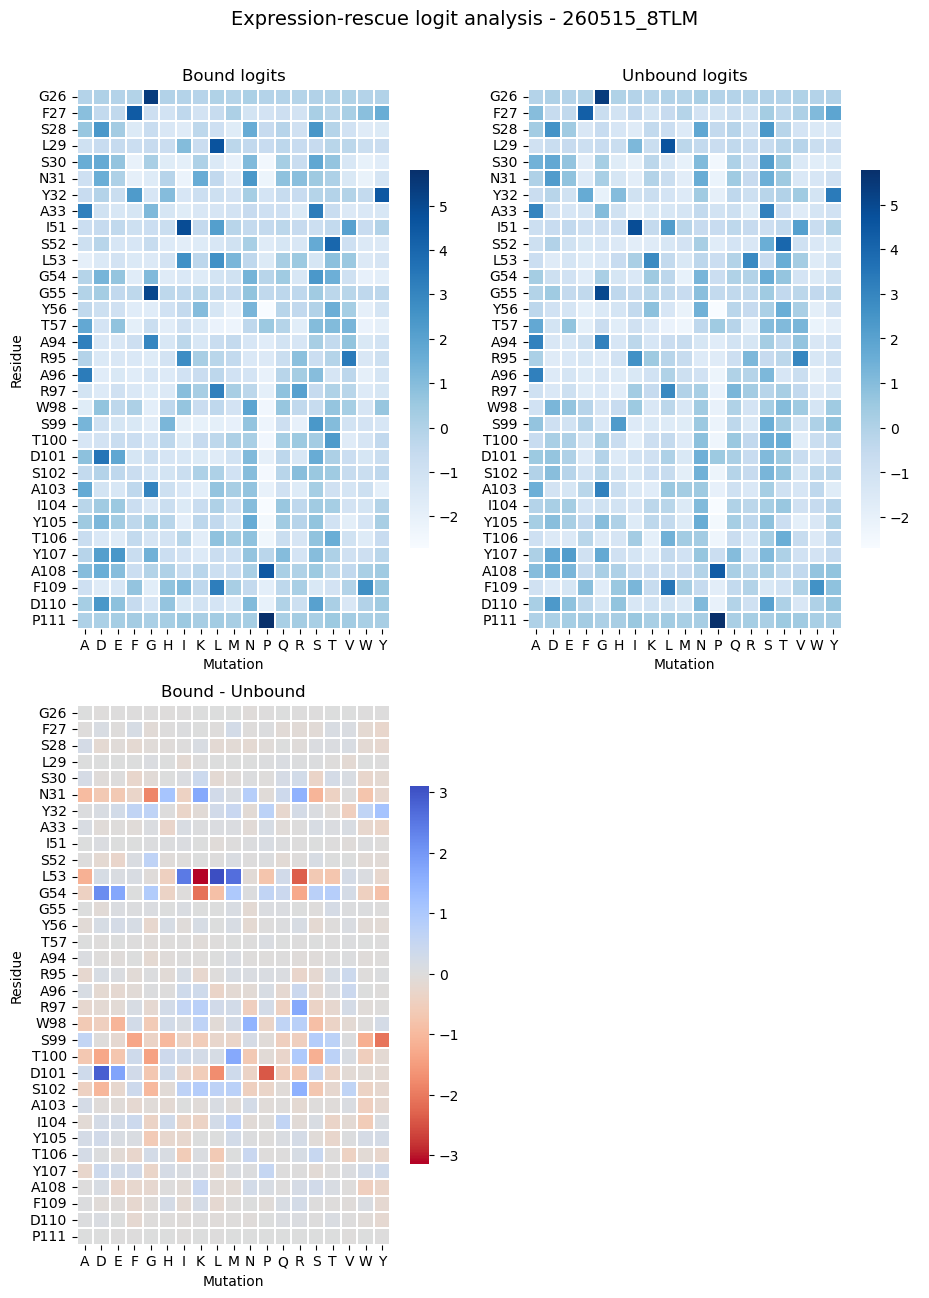

In [9]:
import math

# Color convention: low = red, high = blue.
panels = [
    ("Bound logits", bound_mat, "Blues", None),
    ("Unbound logits", unbound_mat, "Blues", None),
    ("Bound - Unbound", diff_mat, "coolwarm_r", 0.0),
]

# 'C'와 'X'가 있는 열의 인덱스 찾기
cols_to_remove = []
for i, aa in enumerate(alphabet):
    if aa in ("C", "X"):
        cols_to_remove.append(i)

# 'C'와 'X'를 제외한 새로운 alphabet 준비
alphabet_filtered = [aa for i, aa in enumerate(alphabet) if i not in cols_to_remove]

# 각 행렬에서 'C'와 'X' 열 제거
panels_filtered = []
for title, mat, cmap, center in panels:
    if cols_to_remove:
        # 행렬에서 C와 X에 해당하는 열들 제거
        mat_filtered = np.delete(mat, cols_to_remove, axis=1)
    else:
        mat_filtered = mat
    panels_filtered.append((title, mat_filtered, cmap, center))

panels = panels_filtered

# 2열 레이아웃을 위한 행 수 계산 (3개 패널 / 2열 = 2행)
ncols = 2
nrows = math.ceil(len(panels) / ncols)

# figsize 조정: 열 개수와 행 개수에 맞춰 너비와 높이 조절
fig, axes = plt.subplots(
    nrows, ncols, figsize=(ncols * 0.2 * n_aa + 1, nrows * max(4, 0.2 * n_res))
)

# axes는 2D 배열이므로 반복문을 위해 1차원으로 평탄화(flatten)
axes_flat = axes.flatten()

for i, (title, mat, cmap, center) in enumerate(panels):
    ax = axes_flat[i]
    sns.heatmap(
        mat,
        ax=ax,
        cmap=cmap,
        center=center,
        xticklabels=alphabet_filtered,  # X가 제거된 alphabet 사용
        yticklabels=[f"{wt}{res[1:]}" for wt, res in zip(wt_aas, ordered_residues)],
        cbar_kws={"shrink": 0.7},
        linewidths=0.2,
        linecolor="white",
    )
    ax.set_title(title)
    ax.set_xlabel("Mutation")
    # 각 행의 첫 번째 열에만 Residue 라벨 표시
    if i % ncols == 0:
        ax.set_ylabel("Residue")
    else:
        ax.set_ylabel("")

# 데이터가 없는 나머지 subplot (4번째 칸) 숨기기
for j in range(len(panels), len(axes_flat)):
    axes_flat[j].axis("off")

fig.suptitle(f"Expression-rescue logit analysis - {stem}", fontsize=14)
fig.tight_layout()  # 하단 여백 확보 (suptitle과 겹치지 않게)
plt.subplots_adjust(top=0.92)

heatmap_path = output_dir / "heatmap_2col.png"
# fig.savefig(heatmap_path, dpi=200, bbox_inches="tight")
plt.show()

# 결과 해석 및 시각화

파이프라인의 결과를 더 쉽게 이해하기 위해 세 가지 시각화 지표를 제공합니다.

1. Delta Logit 분포: 결합 상태와 비결합 상태 간의 점수 차이 분포를 보여줍니다. 이를 통해 우리가 설정한 `binding_logit_threshold`가 적절한지 확인할 수 있습니다.
2. 회복 후보 산점도: 각 잔기 위치에 대해 '현재 안정성(WT Unbound Logit)'과 '개선 가능성(Delta)'을 비교합니다. 우측 상단에 위치한 잔기일수록 발현 회복을 위한 좋은 후보가 됩니다.
3. 서열 엔트로피 (Sequence Entropy): ProteinMPNN이 각 위치에서 얼마나 특정 아미노산을 확신하는지 보여줍니다. 엔트로피가 낮을수록 해당 위치의 아미노산 선호도가 뚜렷함을 의미합니다.

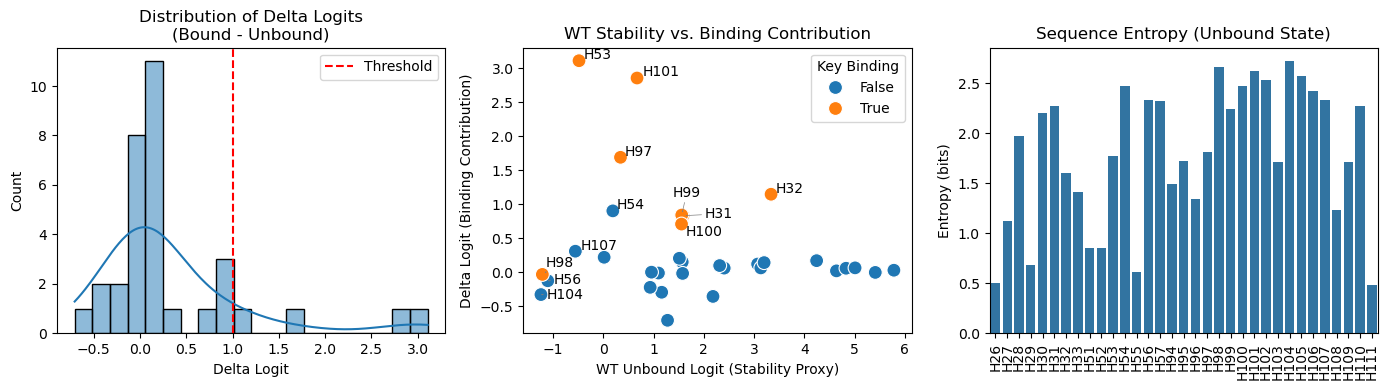

In [ ]:
# 데이터프레임 생성
aa_to_idx = {aa: i for i, aa in enumerate(alphabet)}
df_kb = pd.DataFrame(
    {
        "position": ordered_residues,
        "WT": wt_aas,
        "delta": [
            diff_mat[i, aa_to_idx[wt_aas[i]]] for i in range(len(ordered_residues))
        ],
        "WT_unbound_logit": [
            unbound_mat[i, aa_to_idx[wt_aas[i]]] for i in range(len(ordered_residues))
        ],
    }
)
df_kb["is_final_key_binding"] = df_kb["position"].isin(final_key_binding_positions)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1. Delta Logit Distribution
sns.histplot(df_kb["delta"], kde=True, ax=axes[0])
axes[0].axvline(binding_logit_threshold, color="red", linestyle="--", label="Threshold")
axes[0].set_title("Distribution of Delta Logits\n(Bound - Unbound)")
axes[0].set_xlabel("Delta Logit")
axes[0].legend()

# 2. Mutation Impact Scatter Plot
scatter_df = df_kb.copy()
sns.scatterplot(
    data=scatter_df,
    x="WT_unbound_logit",
    y="delta",
    hue="is_final_key_binding",
    s=100,
    ax=axes[1],
)
texts = []
for i, row in scatter_df.iterrows():
    # 시각적 가독성을 위해 일부 잔기만 이름 표시
    if row["is_final_key_binding"] or row["delta"] > 0.5 or row["WT_unbound_logit"] < 0:
        texts.append(
            axes[1].text(row["WT_unbound_logit"], row["delta"], row["position"])
        )

adjust_text(
    texts,
    ax=axes[1],
    arrowprops={"arrowstyle": "->", "color": "gray", "lw": 0.5},
)

axes[1].set_title("WT Stability vs. Binding Contribution")
axes[1].set_xlabel("WT Unbound Logit (Stability Proxy)")
axes[1].set_ylabel("Delta Logit (Binding Contribution)")
axes[1].legend(title="Key Binding", loc="best")


# 3. Sequence Entropy at Rescue Positions
def calculate_entropy(logits_row: np.ndarray) -> float:
    """로짓(logits) 배열을 기반으로 아미노산 분포의 섀넌 엔트로피(Shannon Entropy)를 계산합니다."""
    # Logits to probabilities
    probs = np.exp(logits_row) / np.sum(np.exp(logits_row))
    return -np.sum(probs * np.log(probs + 1e-9))


entropies = [calculate_entropy(unbound_mat[i]) for i in range(len(ordered_residues))]
entropy_df = pd.DataFrame({"position": ordered_residues, "entropy": entropies})

sns.barplot(data=entropy_df, x="position", y="entropy", ax=axes[2])
axes[2].set_title("Sequence Entropy (Unbound State)")
axes[2].set_ylabel("Entropy (bits)")
axes[2].set_xlabel("")
axes[2].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

## 결과 해석

최종 결과는 Step 6 출력 상단의 녹색 "Final rescue mutations" 박스입니다 . 해당 치환을 항체 서열에 도입하고, 재발현시킨 후 발현율과 결합력을 측정하십시오. 그 외의 모든 것(순위 표, 히트맵, 3D 뷰, 잔기별 CSV)은 이러한 돌연변이가 어떻게 선택되었는지 이해를 돕는 추가 정보입니다. 대부분의 사용자는 최종 목록에 의심스러운 점이 없는 한 이를 무시해도 됩니다.

출력 품질은 입력 구조의 품질에 따라 달라집니다. 이 파이프라인은 잔기별 구조적 컨텍스트(백본 기하 구조 + 주변 환경)를 읽어 모든 후속 결정을 내리는 logit을 생성합니다. 입력된 복합체의 해상도가 낮거나, 잘못 폴딩된 영역이 있거나, 품질이 좋지 않은 경우 결과로 나온 rescue 돌연변이를 신뢰하기 어려울 수 있습니다. 최종 돌연변이 목록이 이상해 보인다면(예: 선택된 위치가 인터페이스에서 너무 멀거나, 명백한 핫스팟에 결합 플래그가 누락된 경우), 임계값을 재조정하기 전에 먼저 입력 구조의 품질을 의심해 보십시오.

돌연변이가 선택된 이유를 더 자세히 알고 싶다면:

- `key_binding_residues.csv` — 어떤 위치가 플래그 지정되었는지 확인 (Δ 기반 + 사용자 지정 + 최종 세트)
- `rescue_ranking.csv` — 전체 정렬 목록; `top_k=True`인 행들이 녹색 박스에 표시된 것들입니다.
- `heatmap.png` — 결합 / 결합 없는 / 차이에 대한 잔기별 20개 아미노산 logit 그리드
- `<stem>_logits.pdb` / `<stem>_unbound_logits.pdb` — 구조의 B-factor에 logit을 입힌 파일 (PyMOL에서 `spectrum b, red_white_blue`로 확인 가능)

In [11]:
# | echo: false
import io

import biotite.sequence.align as align
import biotite.sequence.graphics as graphics
import biotite.sequence.io.fasta as fasta
import matplotlib.pyplot as plt
import numpy as np
from biotite.application.clustalo import ClustalOmegaApp
from matplotlib.colors import LinearSegmentedColormap


def create_similarity_colormap():
    """시각화에 사용할 컬러맵 생성"""
    return LinearSegmentedColormap.from_list(
        "similarity_cmap", [(1.0, 0.3, 0.3), (1.0, 1.0, 1.0)]
    )


def plot_sequence_features(
    ax, alignment, features, num_sequences, line_length, spacing
):
    """서열 특징 정보를 시각화하는 도우미 함수"""
    for row_index in range(1 + len(alignment) // line_length):
        row_start = line_length * row_index
        row_end = min(line_length * (row_index + 1), len(alignment))

        seq_start = alignment.trace[row_start, 1]
        seq_end = alignment.trace[row_end - 1, 1] + 1
        base_y = (num_sequences + spacing) * row_index + num_sequences

        for feat_name, (feat_start, feat_end) in features.items():
            start = feat_start - 1
            end = feat_end

            if start < seq_end and end > seq_start:
                x_start = np.clip(start - seq_start, 0, line_length)
                x_end = np.clip(end - seq_start, 0, line_length)
                x_center = (x_start + x_end) / 2

                # 특징 표시 선 및 텍스트
                ax.plot(
                    [x_start, x_end],
                    [base_y + 0.3] * 2,
                    color="black",
                    linewidth=2,
                    clip_on=False,
                )
                ax.text(
                    x_center, base_y + 0.6, feat_name, fontsize=8, va="top", ha="center"
                )


def perform_alignment(sequences, use_input_order):
    """서열 정렬 수행 함수"""
    if len(sequences) == 2:
        matrix = align.SubstitutionMatrix.std_protein_matrix()
        alignments = align.align_optimal(
            sequences[0],
            sequences[1],
            matrix=matrix,
            gap_penalty=-10,
            terminal_penalty=False,
        )
        return alignments[0], [0, 1]  # 첫 번째 정렬만 반환
    else:
        app = ClustalOmegaApp(sequences)
        app.start()
        app.join()
        return app.get_alignment(), app.get_alignment_order()


def visualize_alignment_with_features(
    fasta_string: str,
    sequence_features: dict[str, tuple[int, int]] | None = None,
    use_input_sequence_order: bool = True,
    figure_size: tuple[int, int] = (8, 4),
    sequence_line_length: int = 40,
    feature_spacing: int = 3,
) -> None:
    """
    FASTA 서열 정렬 및 특징 시각화 함수

    Parameters:
    fasta_string: FASTA 형식의 서열 문자열
    sequence_features: 첫 번째 서열의 특징 위치 정보 (시작, 끝)
    use_input_sequence_order: 입력 순서 유지 여부
    figure_size: 출력 이미지 크기 (가로, 세로)
    sequence_line_length: 줄당 표시할 서열 길이
    feature_spacing: 특징 표시 간격
    """

    # FASTA 데이터 파싱
    fasta_file = io.StringIO(fasta_string)
    seq_dict = fasta.get_sequences(fasta.FastaFile.read(fasta_file))
    sequences = list(seq_dict.values())
    seq_ids = list(seq_dict.keys())

    # 서열 정렬 수행
    alignments, order = perform_alignment(sequences, use_input_sequence_order)

    # 시각화 설정
    fig, ax = plt.subplots(figsize=figure_size)
    colormap = create_similarity_colormap()

    # 정렬 결과 플롯
    graphics.plot_alignment_similarity_based(
        ax,
        alignments,
        matrix=align.SubstitutionMatrix.std_protein_matrix(),
        symbols_per_line=sequence_line_length,
        labels=seq_ids,
        show_numbers=True,
        cmap=colormap,
        label_size=9,
        number_size=9,
        symbol_size=7,
        spacing=feature_spacing,
    )

    # 특징 정보 표시
    if sequence_features:
        plot_sequence_features(
            ax,
            alignments,
            sequence_features,
            len(sequences),
            sequence_line_length,
            feature_spacing,
        )

    plt.tight_layout()
    plt.show()

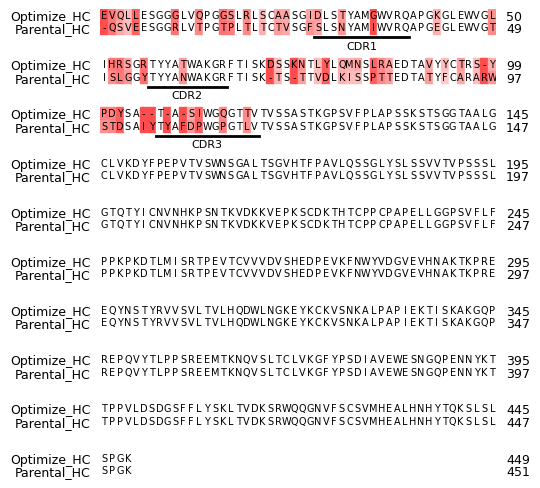

In [ ]:
# | echo: false
# | render: false

fasta_sequence_data = """
>Optimize_HC
EVQLLESGGGLVQPGGSLRLSCAASGIDLSTYAMGWVRQAPGKGLEWVGLIHRSGRTYYA
TWAKGRFTISKDSSKNTLYLQMNSLRAEDTAVYYCTRSYPDYSATASIWGQGTTVTVSSA
STKGPSVFPLAPSSKSTSGGTAALGCLVKDYFPEPVTVSWNSGALTSGVHTFPAVLQSSG
LYSLSSVVTVPSSSLGTQTYICNVNHKPSNTKVDKKVEPKSCDKTHTCPPCPAPELLGGP
SVFLFPPKPKDTLMISRTPEVTCVVVDVSHEDPEVKFNWYVDGVEVHNAKTKPREEQYNS
TYRVVSVLTVLHQDWLNGKEYKCKVSNKALPAPIEKTISKAKGQPREPQVYTLPPSREEM
TKNQVSLTCLVKGFYPSDIAVEWESNGQPENNYKTTPPVLDSDGSFFLYSKLTVDKSRWQ
QGNVFSCSVMHEALHNHYTQKSLSLSPGK
>Parental_HC
QSVEESGGRLVTPGTPLTLTCTVSGFSLSNYAMIWVRQAPGEGLEWVGTISLGGYTYYAN
WAKGRFTISKTSTTVDLKISSPTTEDTATYFCARARWSTDSAIYTYAFDPWGPGTLVTVS
SASTKGPSVFPLAPSSKSTSGGTAALGCLVKDYFPEPVTVSWNSGALTSGVHTFPAVLQS
SGLYSLSSVVTVPSSSLGTQTYICNVNHKPSNTKVDKKVEPKSCDKTHTCPPCPAPELLG
GPSVFLFPPKPKDTLMISRTPEVTCVVVDVSHEDPEVKFNWYVDGVEVHNAKTKPREEQY
NSTYRVVSVLTVLHQDWLNGKEYKCKVSNKALPAPIEKTISKAKGQPREPQVYTLPPSRE
EMTKNQVSLTCLVKGFYPSDIAVEWESNGQPENNYKTTPPVLDSDGSFFLYSKLTVDKSR
WQQGNVFSCSVMHEALHNHYTQKSLSLSPGK
"""

# 첫 번째 서열에 대한 특징 정보 (정렬 후 위치 기반)
first_sequence_features = {
    "CDR1": (27, 38),
    "CDR2": (56, 65),
    "CDR3": (105, 117),
}

# 함수 호출 예시
visualize_alignment_with_features(
    fasta_sequence_data,
    sequence_features=first_sequence_features,
    use_input_sequence_order=True,
    figure_size=(5.5, 5),
    sequence_line_length=50,
    feature_spacing=2,
)


# 마치며

예측을 통해 추천되는 돌연변이 상위 9개 대하여 실제 최적화를 통해 얻은 서열을 서로 비교해보니 다음 표와 같았습니다. 최적화된 서열을 인간화(Humanize)를 우선한 것이라 예측 결과와 각각을 비교하는 것은 옳지 않다고 생각합니다. 그래도 꽤나 흥미로운 결과라고 받아들이면 될 것 같습니다.

추천 돌연변이 | 실제 돌연변이
---|---
I104N | deletion
Y56T | Y56R
Y107E | deletion
Y105N | deletion
G54S | G54S
F109L | deletion
A108P | WT
T57A | WT
R95V | R95R
